In [1]:
# Bayesian MMM

In [2]:
# 1. Load Data

In [3]:
from importlib.metadata import distribution

import numpy as np
import pandas as pd
import os

from streamlit import dataframe
from supabase import create_client, Client
from dotenv import load_dotenv
import datetime as dt

def extract_data_supabase():
    # Read the environment variables from .env
    load_dotenv(dotenv_path ="../.env")

    # initialise Supabase client side
    url = os.environ.get("SUPABASE_URL")
    key = os.environ.get("SUPABASE_KEY")

    supabase = create_client(url, key)

    # extract data from Supabase
    response = supabase.table('marketing_spend_weekly').select("*").execute()

    # convert the response to dataframe
    dataframe_raw = pd.DataFrame(response.data)
    dataframe_raw['date'] = pd.to_datetime(dataframe_raw['date'], format = "%Y-%m-%d")
    dataframe_raw = dataframe_raw.sort_values(by = "date").reset_index(drop = True)

    return dataframe_raw


In [4]:
df = extract_data_supabase()
df.head(3)


,date,PPC_Brand_Spend,PPC_Generic_Spend,Display_Spend,Social_Spend,TV_Spend,OOH_Spend,Meta_Spend,Yahoo_Spend,competitor_spend,google_trend_competitor,opportunities,sales
0,2020-01-06,33606.667083,12359.075216,9986.110339,7553.655263,23057.166184,12462.531065,5376.929177,2276.638237,52119.484639,48.902186,2169.368536,258.949354
1,2020-01-13,24275.884049,14434.738310,15002.644018,8079.099846,20604.238251,11626.697707,5276.868373,1949.054037,45134.452504,55.010903,2450.723580,303.521532
2,2020-01-20,24797.574326,12666.330243,13383.768500,8005.664941,27517.645795,12093.366880,4735.128755,2502.308650,47586.047249,41.571042,2279.740794,278.043856


In [5]:
# 2. EDA

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     260 non-null    datetime64[us]
 1   PPC_Brand_Spend          260 non-null    float64       
 2   PPC_Generic_Spend        260 non-null    float64       
 3   Display_Spend            260 non-null    float64       
 4   Social_Spend             260 non-null    float64       
 5   TV_Spend                 260 non-null    float64       
 6   OOH_Spend                260 non-null    float64       
 7   Meta_Spend               260 non-null    float64       
 8   Yahoo_Spend              260 non-null    float64       
 9   competitor_spend         260 non-null    float64       
 10  google_trend_competitor  260 non-null    float64       
 11  opportunities            260 non-null    float64       
 12  sales                    260 non-null    float6

In [7]:
df.describe()

,date,PPC_Brand_Spend,PPC_Generic_Spend,Display_Spend,Social_Spend,TV_Spend,OOH_Spend,Meta_Spend,Yahoo_Spend,competitor_spend,google_trend_competitor,opportunities,sales
count,260,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,2022-06-30 12:00:00,19735.899191,13136.112552,8793.107400,6595.066409,28527.635323,11120.996064,8220.952419,2822.098502,45441.832747,50.662365,2341.239982,280.536179
min,2020-01-06 00:00:00,8558.177532,5282.778603,3656.354172,2984.425350,12365.716302,5061.183000,3254.041378,1264.525200,34908.896055,20.374122,1761.834301,205.206107
25%,2021-04-03 06:00:00,13964.194713,9501.541423,6344.030735,4591.337161,20453.940395,8228.523552,5615.895369,1969.168915,42087.705866,41.911625,2161.955703,257.128199
50%,2022-06-30 12:00:00,18794.439572,12581.488002,8302.158850,6433.460558,27379.206092,10974.735370,7534.764133,2761.226352,45137.388839,51.618656,2355.327330,280.554883
75%,2023-09-26 18:00:00,24400.922530,15803.095511,10698.147677,7943.224957,35355.252909,13393.190596,10177.572763,3482.626293,47701.007667,59.951868,2528.691974,302.746704
max,2024-12-23 00:00:00,52458.421412,42534.503106,22318.497274,16330.085642,64686.420827,27568.474234,29026.416504,8603.180065,63565.262244,80.390182,2960.950661,350.582216
std,NaN,7106.512196,5107.018934,3146.915683,2436.849771,9654.987882,3568.798428,3532.705466,1034.607915,4679.550568,12.106800,255.896876,31.733694


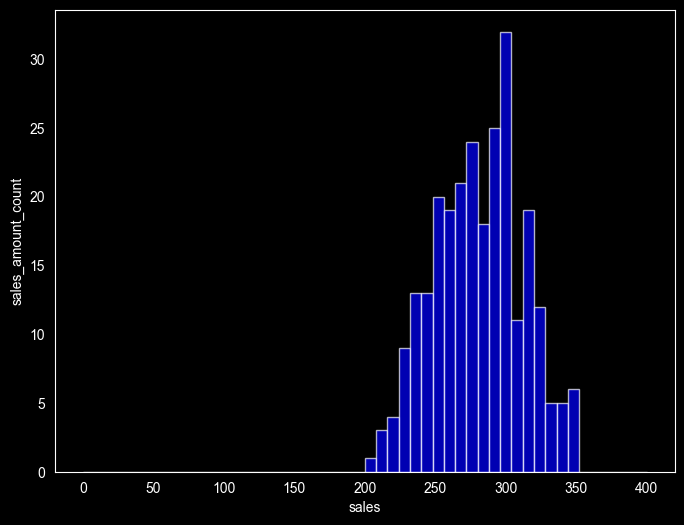

In [8]:
# plot sales distribution
# sales is between 200 and 350
import matplotlib.pyplot as plt
plt.figure(figsize = (8,6))
plt.hist(x=df['sales'],
         bins=50,
         range = (0, 400),
         color = 'blue'
         ,alpha = 0.7)
plt.grid(False)
plt.xlabel('sales')
plt.ylabel('sales_amount_count')
plt.show()

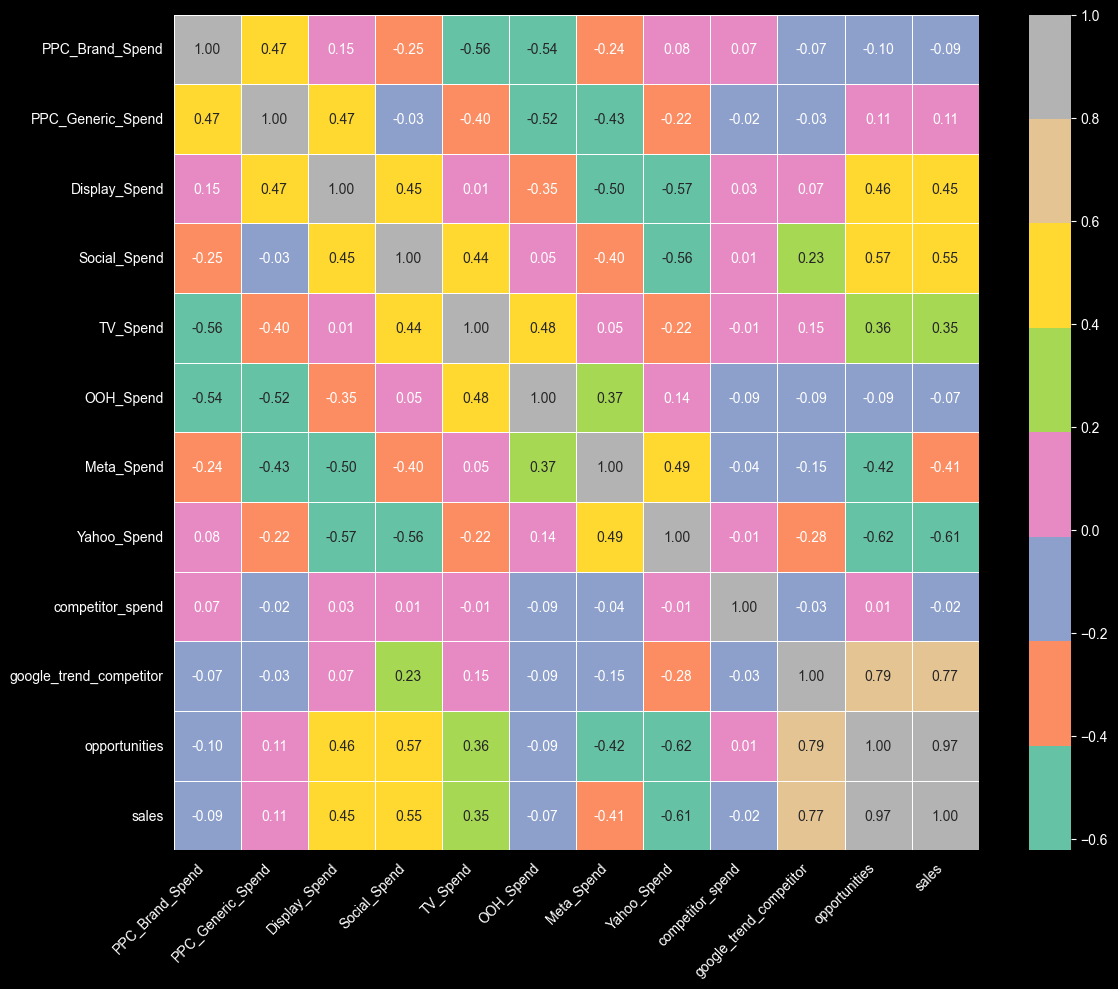

In [9]:
# create correlation matrix
import seaborn as sns
df_n = df.select_dtypes(include = np.number)
df_n2 = pd.DataFrame(df_n)
corr_matrix = df_n2.corr().astype(float)

plt.figure(figsize = (12,10))

sns.heatmap(data = corr_matrix,
            xticklabels = corr_matrix.columns,
            yticklabels = corr_matrix.columns,
            annot = True,
            cmap = 'Set2',
            linewidths = .5,
            fmt = '.2f',
            annot_kws = {"size":10})
plt.xticks(rotation = 45, ha = "right")

plt.tight_layout()



In [10]:
# as we build bayesian MMM, we won't group the channels that have medium correlation. We can't find out which channel has higher beta(coefficient). In Bayesian MMM, we set Priors based on previous performance. e.g. Meta is 20% higher conversion than Yahoo. we will set Meta beta = 3.6 Yahoo beta = 3
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs!=1]
high_corr = corr_pairs[corr_pairs>=0.45].drop_duplicates().sort_values(ascending=False)
print(high_corr)

opportunities            sales                0.969850
google_trend_competitor  opportunities        0.787109
                         sales                0.773949
Social_Spend             opportunities        0.573315
                         sales                0.552124
Meta_Spend               Yahoo_Spend          0.485949
TV_Spend                 OOH_Spend            0.481392
PPC_Generic_Spend        Display_Spend        0.474575
PPC_Brand_Spend          PPC_Generic_Spend    0.474167
Display_Spend            opportunities        0.457197
                         Social_Spend         0.453981
dtype: float64


In [11]:
# Feature Engineering

In [12]:
def data_process(dataset: pd.DataFrame):
    spend_cols = [x for x in dataset.columns if x.lower().endswith('_spend') ]

    #check columns name end with Spend or not
    # or use
    # spend_cols = df.columns[df.columns.str.endswith('_Spend')].tolist()
    # spend_cols

    spend_per_channel = dataset[spend_cols].sum(axis=0)
    spend_per_channel_pct = spend_per_channel/spend_per_channel.sum(axis=0)

    # specify sigma parameter per channel
    n_channels = 9
    prior_sigma = n_channels * spend_per_channel_pct
    return prior_sigma.tolist()

In [13]:
prior_sigma_list = data_process(df)
prior_sigma_list

[1.2301304833546796,
 0.8187684952370159,
 0.5480707694517052,
 0.41106777812187983,
 1.7781157822417968,
 0.6931671129484093,
 0.5124085847034062,
 0.1759002395111769,
 2.8323707544299315]

In [14]:
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.multidimensional import MMM
# def mmm_model(dataset: pd.DataFrame, prior_sigma: float):
# X = df.drop('sales', axis=1)
# y = df['sales']

dummy_model = MMM(
    date_column="",
    channel_columns=[""],
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
)
dummy_model.default_model_config


C:\Users\ipnga\PycharmProjects\bayesian-mmm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

In [17]:
from pymc_marketing.prior import Prior
alpha_list = [1,1,1,1,3,3,1,1,1]
beta_list = [3,3,3,3,1,1,3,3,3]

my_model_config = {
    'intercept': Prior("Normal", mu=0.5, sigma=2),
    'saturation_beta': Prior("HalfNormal", sigma=prior_sigma_list, dims="channel"),
    'gamma_control': Prior("Normal", mu=0, sigma=0.5, dims="control"),
    'gamma_fourier': Prior("Laplace", mu=0, b=0.5, dims="fourier_mode"),
    'adstock_alpha': Prior("Beta", alpha=alpha_list, beta=beta_list, dims="channel"),
    'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
    'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=6))}

In [15]:
df.columns

Index(['date', 'PPC_Brand_Spend', 'PPC_Generic_Spend', 'Display_Spend',
       'Social_Spend', 'TV_Spend', 'OOH_Spend', 'Meta_Spend', 'Yahoo_Spend',
       'competitor_spend', 'google_trend_competitor', 'opportunities',
       'sales'],
      dtype='str')